# PROGETTO di Ghiani Caterina
### *Corso di Introduzione alla data science e al pensiero computazionale - anno accademico 2025/2026*
### **Caterina Ghiani:** matricola 1181102, caterina.ghiani@studio.unibo.it

# 0. Preparazione dell'ambiente
### prima di iniziare la nostra analisi, bisogna importare le librerie necessarie

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import svm, tree
from sklearn.metrics import *

# 1. Descrizione e comprensione del dataset

Questo dataset contiene informazioni relative ai clienti di carte di credito, inclusi dati demografici, limiti di credito, cronologia delle fatturazioni e storico dei pagamenti. Ogni record rappresenta un cliente e fornisce diverse variabili utili per valutare l'affidabilità finanziaria.

L'obiettivo della classificazione è prevedere se un cliente andrà in default (inadempienza) sul pagamento del mese successivo. La variabile target indica se il cliente non ha rispettato gli obblighi di pagamento nel mese seguente. Questo problema è particolarmente rilevante nel settore finanziario, dove i modelli predittivi aiutano gli istituti a identificare i clienti ad alto rischio e a supportare le decisioni di gestione del credito.

La ricerca utilizza una variabile binaria come risposta: default payment (Sì = 1, No = 0).

In [ ]:
credit = pd.read_csv("Credit_Card_Default.csv", header=1) #questo per eliminare la riga con scritto X1, X2, etc.

In [ ]:
credit

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


La nostra variabile target è "default payment next month" è la nostra Y

### 1. Pulizia dataset

In [ ]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

In [ ]:
if 'ID' in credit.columns:
    credit = credit.drop(columns=['ID']) # eliminiamo questa "feature" perchè non aggiunge niente alla nostra analisi, è solo un identificativo


In [ ]:
credit_num_righe = credit.shape[0]
credit_num_colonne = credit.shape[1]
print("Numero righe", credit_num_righe)
print("Numero colonne", credit_num_colonne)

print()

Numero righe 30000
Numero colonne 24



Rinominiamo PAY_0 in PAY_1 per coerenza con il nome delle altre variabili, supponendo sia stata una svista da parte di chi ha inviato il dataset

In [ ]:
credit = credit.rename(columns={'PAY_0': 'PAY_1'})

Andiamo alla ricerca di valori nulli e osserviamo che non ce ne sono

In [ ]:
print(credit.isnull().sum())

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_1                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64


Cerchiamo di capire che valori possono assumere le nostre variabili categoriali

In [ ]:
list_cat = ["SEX", "EDUCATION", "MARRIAGE", "PAY_1", "PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

In [ ]:
for stringa in list_cat:
  unici = credit[stringa].unique()
  print(stringa)
  print(unici)

SEX
[2 1]
EDUCATION
[2 1 3 5 4 6 0]
MARRIAGE
[1 2 3 0]
PAY_1
[ 2 -1  0 -2  1  3  4  8  7  5  6]
PAY_1
[ 2 -1  0 -2  1  3  4  8  7  5  6]
PAY_2
[ 2  0 -1 -2  3  5  7  4  1  6  8]
PAY_3
[-1  0  2 -2  3  4  6  7  1  5  8]
PAY_4
[-1  0 -2  2  3  4  5  7  6  1  8]
PAY_5
[-2  0 -1  2  3  5  4  7  8  6]
PAY_6
[-2  2  0 -1  3  6  4  7  8  5]


Osserviamo che le variabili PAY_X, le quali esprimono di quanti mesi è in ritardo il titolare della carta nei pagamenti, possono assumere anche valori diversi da quelli indicati nella legenda. Valori quali: -2 e 0. Assumendo che questi valori significhino che il titolare o non ha debiti da pagare o ha già pagato il minimo per non essere in morosità ricodifichiamo le variabili. Nel momento in cui assumono valori quali -2, -1 e 0 consideriamo il cliente solvente e quindi le ricodifichiamo con 0.

In [ ]:
cols_pay = ["PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
mapping = {-2:0,
           -1:0,
            0:0
}

for col in cols_pay:
  credit[col] = credit[col].replace(mapping) # applica la nuova mappatura

for col in cols_pay:
    print(f"{col}: {credit[col].unique()}") #verifica dei valori unici

PAY_1: [2 0 1 3 4 8 7 5 6]
PAY_2: [2 0 3 5 7 4 1 6 8]
PAY_3: [0 2 3 4 6 7 1 5 8]
PAY_4: [0 2 3 4 5 7 6 1 8]
PAY_5: [0 2 3 5 4 7 8 6]
PAY_6: [0 2 3 6 4 7 8 5]


La medesima osservazione fatta per PAY_X si può fare anche per EDUCATION. Secondo la legenda infatti, la variabile potrebbe assumere solo 4 valori, mentre invece assume anche il valore 0, 5 e 6. Dopo aver capito quante osservazioni assumono i valori non codificati, procediamo con la ricodifica di questi valori "anomali" all'interno della categoria 4 - Other, siccome non possiamo escludere osservazioni dalla nostra analisi e non possiamo attribuire un significato univoco a questi valori.

In [ ]:
print(credit['EDUCATION'].value_counts())

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64


In [ ]:
mapping = { 0:4,
            5:4,
            6:4
}

credit['EDUCATION'] = credit['EDUCATION'].replace(mapping) # applica la nuova mappatura

print(credit['EDUCATION'].unique())

[2 1 3 4]


La medesima situazione la ritroviamo anche in MARRIAGE, dove la variabile ha assunto 54 volte anche il valore 0. Anche in questa situazione ricodifichiamo i valori che assumono 0, nella categoria 3 che corrisponde a "Other"

In [32]:
print(credit['MARRIAGE'].value_counts())

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


In [33]:
credit['MARRIAGE'] = credit['MARRIAGE'].replace({0: 3})

print(credit['MARRIAGE'].unique())

[1 2 3]


Per comodità per l'interpretazione dei modelli, ricodificiamo anche la variabile SEX in modo che maschio = 0 e femmina = 1

In [34]:
mapping = { 1:0, # maschio
            2:1  # femmina
}

credit['SEX'] = credit['SEX'].replace(mapping) # applica la nuova mappatura

print(credit['SEX'].unique())

[1 0]


### Statistiche descrittive fondamentali

**2. Qual è la distribuzione della variabile target?**

In [35]:
counts = credit['default payment next month'].value_counts()
perc = credit['default payment next month'].value_counts(normalize=True) * 100

target_dist = pd.DataFrame({
    'Conteggio (N)': counts,
    'Percentuale (%)': perc.round(2),
})

target_dist.index = ['Solvibile (0)', 'Default (1)']

print("--- DISTRIBUZIONE DELLA VARIABILE TARGET ---")
print(target_dist)

--- DISTRIBUZIONE DELLA VARIABILE TARGET ---
               Conteggio (N)  Percentuale (%)
Solvibile (0)          23364            77.88
Default (1)             6636            22.12


Il 3/4 dei soggetti osservati è solvibile, mentre 1/4 è in default. Questo rende il nostro dataset sbilanciato rispetto alla variabile target.

**3. Quali sono le caratteristiche anagrafiche dei nostri soggetti?**

In [36]:
list_cat = ["SEX", "EDUCATION", "MARRIAGE"]
for stringa in list_cat:
  print("---")
  freq_credit = credit[stringa].value_counts(normalize=True)*100
  print("Credit:", freq_credit)

---
Credit: SEX
1    60.373333
0    39.626667
Name: proportion, dtype: float64
---
Credit: EDUCATION
2    46.766667
1    35.283333
3    16.390000
4     1.560000
Name: proportion, dtype: float64
---
Credit: MARRIAGE
2    53.213333
1    45.530000
3     1.256667
Name: proportion, dtype: float64



*   Il 60% del campione è composto da donne
*   Circa la metà delle persone ha ricevuto un'educazione universitaria, e il 35% ha poi proseguito gli studi
*   Il 53% dei soggetti è single





**4. Qual è la distribuzione dell'età dei clienti? Quali sono le metriche principali?**

In [ ]:
credit["AGE"].describe()

,AGE
count,30000.000000
mean,35.485500
std,9.217904
min,21.000000
25%,28.000000
50%,34.000000
75%,41.000000
max,79.000000


Il nostro dataset comprende soggetti dai 21 ai 79 anni, ma 3/4 dei soggetti hanno meno di 41 anni, implicando che i soggetti in età più adulta o anziani non sono granché rappresentati nel nostro campione di popolazione. La media è di 35 anni, questo vuol dire che probabilmente il valore 79 rappresenta un outlier. Vale la pena quindi rappresentare la variabile età per comprenderne la dispersione.

**5. Come si distribuisce il limite di credito accordato?**

In [30]:
credit['LIMIT_BAL'].describe().round(2)

,LIMIT_BAL
count,30000.00
mean,167484.32
std,129747.66
min,10000.00
25%,50000.00
50%,140000.00
75%,240000.00
max,1000000.00


La media del credito è di 167.484,32 dollari, con una forte deviazione standard. La mediana è inferiore alla media, evidenziando una distribuzione asimmetrica a destra. Difatti, pochi clienti hanno crediti molto elevati e lo possiamo notare anche dal massimo del credito concesso, che è pari a 1 milione.

**6. Quali sono i valori assunti dalle variabili nello storico dei pagamenti?**

In [22]:
# Calcola la distribuzione percentuale delle classi di ritardo per tutte le colonne PAY_X
pay_cols = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Tabella delle frequenze percentuali (arrotondata a 2 cifre decimali)
pay_distribution = credit[pay_cols].apply(lambda x: x.value_counts(normalize=True) * 100).fillna(0).round(2)
pay_distribution.index.name = 'Mesi di ritardo'
pay_distribution

,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
Mesi di ritardo,,,,,,
0,77.27,85.21,85.96,88.30,90.11,89.74
1,12.29,0.09,0.01,0.01,0.00,0.00
2,8.89,13.09,12.73,10.53,8.75,9.22
3,1.07,1.09,0.80,0.60,0.59,0.61
4,0.25,0.33,0.25,0.23,0.28,0.16
5,0.09,0.08,0.07,0.12,0.06,0.04
6,0.04,0.04,0.08,0.02,0.01,0.06
7,0.03,0.07,0.09,0.19,0.19,0.15
8,0.06,0.00,0.01,0.01,0.00,0.01


Circa l'80% dei soggetti è in pari coi pagamenti alla fine del mese, con un picco del 90% nel mese di aprile. Inoltre, si può notare come i soggetti in ritardo sono solitamente in ritardo di 2 mesi rispetto ai pagamenti.

**7. Qual è l'importo medio delle bollette mensili?**

In [28]:
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

bill_distribution = credit[bill_cols].describe().round(2)

bill_distribution

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,51223.33,49179.08,47013.15,43262.95,40311.40,38871.76
std,73635.86,71173.77,69349.39,64332.86,60797.16,59554.11
min,-165580.00,-69777.00,-157264.00,-170000.00,-81334.00,-339603.00
25%,3558.75,2984.75,2666.25,2326.75,1763.00,1256.00
50%,22381.50,21200.00,20088.50,19052.00,18104.50,17071.00
75%,67091.00,64006.25,60164.75,54506.00,50190.50,49198.25
max,964511.00,983931.00,1664089.00,891586.00,927171.00,961664.00


La media dell'importo delle bollette aumenta man mano che si progredisce nell'anno e in tutti i mesi, la media è più del doppio della mediana. Il 50% dei clienti ha bollette contenute e di circa gli stessi importi, mentre pochi clienti accumulano saldi estramamente elevati. I valori negativi non sono un errore, ma implicano un credito a favore del cliente.

**8. Quali sono le statistiche sui pagamenti effettuati?**

In [29]:
pag_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

pag_distribution = credit[pag_cols].describe().round(2)

pag_distribution

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50
std,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,1000.00,833.00,390.00,296.00,252.50,117.75
50%,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00
75%,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00
max,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00


La media dei pagamenti è pressochè la stessa per tutti e 6 i mesi, ed è più del doppio della mediana, confermando che ci sono soggetti che accumulano crediti importanti ma che poi li ripagano anche.

### Analisi esplorativa

***Ipotesi di ricerca:***

1.   L'età differisce in modo significativo tra clienti in default e clienti solvibili?
2.   Un livello d'istruzione più elevato si associa ad una maggiore probabilità di essere solvibile?
3.   Esiste una differenza in base al genere che rende i soggetti più o meno probabili di essere in default?
4.   Un soggetto sposato è più probabile che vada in default?
5.   Un limite di credito concesso più basso segnala un soggetto più a rischio di default?
6.   Un elevato rapporto tra spesa mensile e prestito concesso, aumenta la probabilità di default? Cioè chi usa sempre al massimo il credito concesso, alla fine va in default più spesso di chi invece non raggiunge il tetto di spesa?

**1. L'età differisce in modo significativo tra clienti in default e solvibili?**

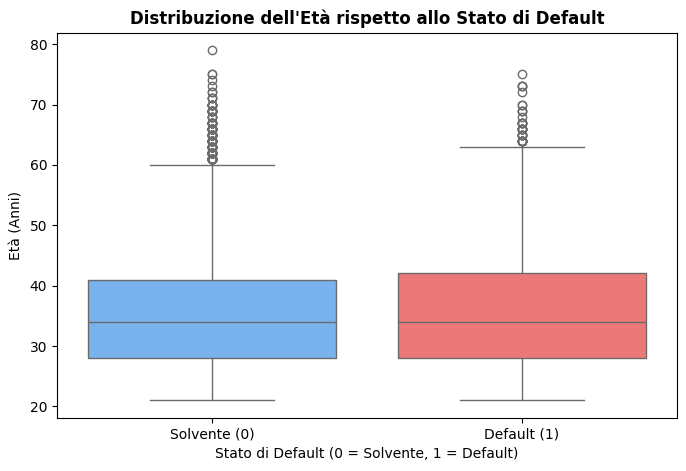

<Figure size 640x480 with 0 Axes>

In [42]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='default payment next month',
    y='AGE',
    hue = 'default payment next month',
    data = credit,
    palette=['#66b2ff', '#ff6666'],
    legend = False
)
plt.title('Distribuzione dell\'Età rispetto allo Stato di Default', fontsize=12, fontweight='bold')
plt.xlabel('Stato di Default (0 = Solvente, 1 = Default)')
plt.ylabel('Età (Anni)')
plt.xticks([0, 1], ['Solvente (0)', 'Default (1)'])
plt.show()

# Salvataggio per la relazione in LaTeX
plt.savefig('boxplot_age_target.png', dpi=300, bbox_inches='tight')
plt.show()

In [40]:
# Età per stato di Solvibilità
credit.groupby('default payment next month')['AGE'].agg(['mean', 'median', 'std']).round(2)

,mean,median,std
default payment next month,,,
0,35.42,34.0,9.08
1,35.73,34.0,9.69


Dall'analisi del boxplot complessivo per la variabile ***AGE***, si rileva una mediana pari a circa 34 anni, con un range interquartile compreso tra 28 e 41 anni. La presenza di valori anomali statistici sopra i 60 anni rispecchia la naturale distribuzione demografica dei titolari di carta di credito e non costituisce un errore nei dati.

Il confronto bivariato rispetto alla variabile target Y evidenzia una quasi totale sovrapposizione tra la distribuzione dei clienti solvibili Y=0 e quelli in default Y=1. Ciò suggerisce che l'età, non è un fattore che determina la capacità di ripagare i propri debiti

**2. Un elevato livello d'istruzione si associa ad una minore probabiltà di default?**

--- CONFRONTO SOLVIBILI/INSOLVENTI PER TITOLO DI STUDIO ---
                                    Solvibili (N)  Insolventi (N)  Totale (N)  \
(1) Specialistica/master/dottorato           8549            2036       10585   
(2) Università                              10700            3330       14030   
(3) Scuola superiore                         3680            1237        4917   
(4) Altro                                     435              33         468   
Totale                                      23364            6636       30000   

                                    Solvibili (%)  Insolventi (%)  
(1) Specialistica/master/dottorato          80.77           19.23  
(2) Università                              76.27           23.73  
(3) Scuola superiore                        74.84           25.16  
(4) Altro                                   92.95            7.05  
Totale                                      77.88           22.12  


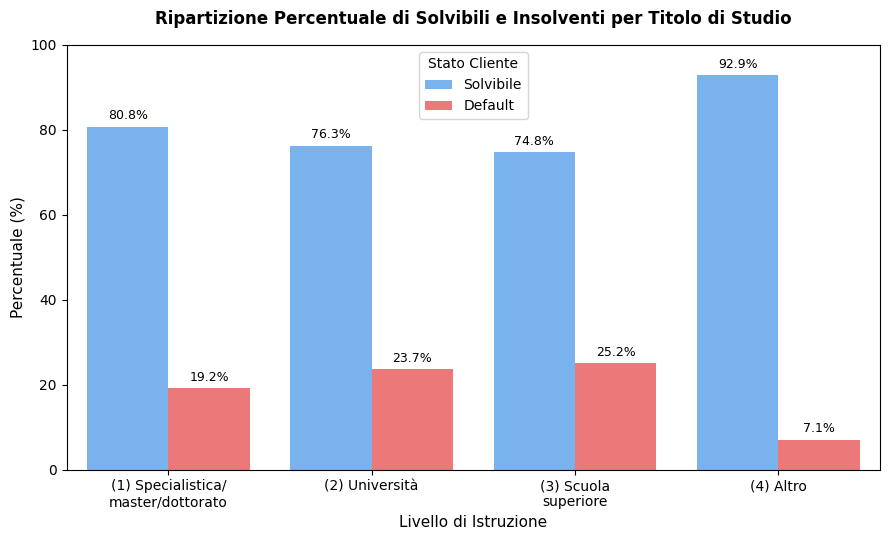

In [44]:
edu_labels = {
    1: '(1) Specialistica/master/dottorato',
    2: '(2) Università',
    3: '(3) Scuola superiore',
    4: '(4) Altro',
}


# TABELLA
# Conteggi assoluti (N)
ct_counts = pd.crosstab(
    credit['EDUCATION'],
    credit['default payment next month'],
    margins=True,
    margins_name='Totale',
)

# Percentuali di riga (%)
ct_pct = (
    pd.crosstab(
        credit['EDUCATION'],
        credit['default payment next month'],
        normalize='index',
    )
    * 100
)

# DataFrame unificato
df_table = pd.DataFrame({
    'Solvibili (N)': ct_counts[0],
    'Insolventi (N)': ct_counts[1],
    'Totale (N)': ct_counts['Totale'],
})

df_table['Solvibili (%)'] = ct_pct[0].round(2)
df_table['Insolventi (%)'] = ct_pct[1].round(2)

# Assegnazione corretta delle percentuali globali alla riga Totale
df_table.loc['Totale', 'Solvibili (%)'] = round(
    (ct_counts.loc['Totale', 0] / ct_counts.loc['Totale', 'Totale']) * 100, 2
)
df_table.loc['Totale', 'Insolventi (%)'] = round(
    (ct_counts.loc['Totale', 1] / ct_counts.loc['Totale', 'Totale']) * 100, 2
)

# Formattazione degli indici della tabella
df_table.index = [
    edu_labels.get(i, 'Totale') for i in df_table.index[:-1]
] + ['Totale']

print("--- CONFRONTO SOLVIBILI/INSOLVENTI PER TITOLO DI STUDIO ---")
print(df_table)


# 2. GRAFICO A BARRE AFFIANCATE

credit_plot = credit.copy()
credit_plot['EDUCATION_LABEL'] = credit_plot['EDUCATION'].map(edu_labels)
credit_plot['TARGET_LABEL'] = credit_plot[
    'default payment next month'
].map({0: 'Solvibile', 1: 'Default'})

# Calcolo delle percentuali relative per gruppo di Istruzione
df_chart = (
    credit_plot.groupby(['EDUCATION_LABEL', 'TARGET_LABEL'])
    .size()
    .reset_index(name='Count')
)
df_chart['Percentuale'] = df_chart.groupby('EDUCATION_LABEL')['Count'].transform(
    lambda x: 100 * x / x.sum()
)
df_chart = df_chart.drop(columns=['Count'])

plt.figure(figsize=(9, 5.5))


ax = sns.barplot(
    data=df_chart,
    x='EDUCATION_LABEL',
    y='Percentuale',
    hue='TARGET_LABEL',
    hue_order=['Solvibile', 'Default'],
    palette=['#66b2ff','#ff6666'],
    order=[
        '(1) Specialistica/master/dottorato',
        '(2) Università',
        '(3) Scuola superiore',
        '(4) Altro',
    ],
)


plt.title(
    'Ripartizione Percentuale di Solvibili e Insolventi per Titolo di Studio',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Livello di Istruzione', fontsize=11)
plt.ylabel('Percentuale (%)', fontsize=11)
plt.legend(title='Stato Cliente', frameon=True)

# Formatting delle etichette sull'asse X
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=[
        '(1) Specialistica/\nmaster/dottorato',
        '(2) Università',
        '(3) Scuola\nsuperiore',
        '(4) Altro',
    ],
    fontsize=10,
)

# Annotazione delle percentuali sopra ciascuna barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            xytext=(0, 3),
            textcoords='offset points',
            fontsize=9,
        )

plt.ylim(0, 100)
plt.tight_layout()

# Salvataggio della figura
plt.savefig('education_stacked_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()



*   al diminuire del grado del titolo di studio aumenta il tasso di default: ad un'istruzione più elevata si associa una maggiore probabilità di solvibilità supponendo che sia legata ad un reddito medio più stabile
*   i clienti codificati come "Altro" includono anche le anomalie che prima abbiamo ricodificato e registrano un tasso di default estremamente basso (7.1%). Questo potrebbe essere dovuto al fatto che corrispondano a categorie particolari, probabilmente a categorie di soggetti sui quali la stessa banca fa uno screening più approfondito per verificarne l'affidabilità.



--- DISTRIBUZIONE DEFAULT PER GENERE (VALORI ASSOLUTI E %) ---
             Solvibili (N)  Solvibili (%)  Default (N)  Default (%)  \
Maschio (0)           9015          75.83         2873        24.17   
Femmina (1)          14349          79.22         3763        20.78   

             Totale Clienti  
Maschio (0)           11888  
Femmina (1)           18112  


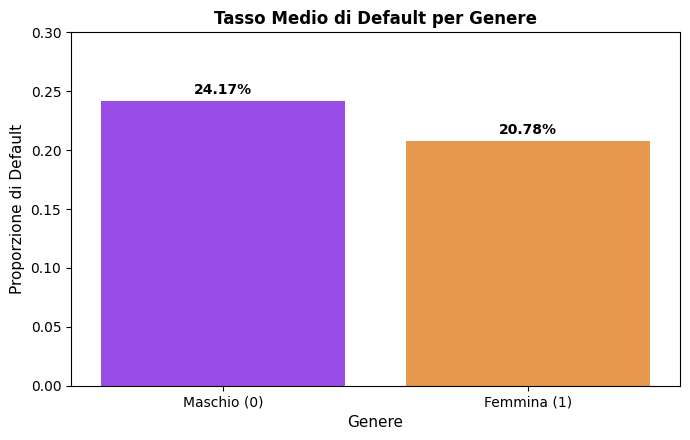

In [ ]:
# 1. Tabella dei valori assoluti + percentuali
ct_counts = pd.crosstab(credit['SEX'], credit['default payment next month'])

ct_pct = (
    pd.crosstab(
        credit['SEX'], credit['default payment next month'], normalize='index'
    )
    * 100
)

ct_combined = pd.DataFrame({
    'Solvibili (N)': ct_counts[0],
    'Solvibili (%)': ct_pct[0].round(2),
    'Default (N)': ct_counts[1],
    'Default (%)': ct_pct[1].round(2),
    'Totale Clienti': ct_counts.sum(axis=1),
})

# Rinominiamo gli indici di riga
ct_combined.index = ['Maschio (0)', 'Femmina (1)']

print("--- DISTRIBUZIONE DEFAULT PER GENERE (VALORI ASSOLUTI E %) ---")
print(ct_combined)

# 2. Grafico delle percentuali di Default per Genere
plt.figure(figsize=(7, 4.5))

ax = sns.barplot(
    data=credit,
    x='SEX',
    y='default payment next month',
    hue='SEX',
    palette=['#9933ff', '#ff9933'],
    errorbar=None,
    legend=False,
)

plt.title(
    'Tasso Medio di Default per Genere', fontsize=12, fontweight='bold'
)
plt.xlabel('Genere', fontsize=11)
plt.ylabel('Proporzione di Default', fontsize=11)
plt.xticks(ticks=[0, 1], labels=['Maschio (0)', 'Femmina (1)'])

# percentuale sopra ogni barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.2%}',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        xytext=(0, 3),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
    )

plt.ylim(0, 0.3)
plt.tight_layout()
plt.savefig('default_by_sex.png', dpi=300, bbox_inches='tight')
plt.show()

Confrontando le percentuali normalizzate, le donne hanno un tasso di insolvenza inferiore rispetto agli uomini. La popolazione femminile risulta più affidabile. A causa delle sproporzione nel portafoglio clienti (le donne sono il 60%), in valori assoluti le donne superano gli uomini nei casi di default.

**5. Un soggetto sposato è più probabile che sia solvibile?**

In [52]:
#1: sposato/a
#2: single
#3: altro

credit.groupby('MARRIAGE')['default payment next month'].mean().round(3) * 100

,default payment next month
MARRIAGE,
1,23.5
2,20.9
3,23.6


Considerazioni:


*   le categorie "sposato/a" e "single" sono approssimativamente bilanciate avendo rispettivamente 13.659 e 15.964 soggetti osservati
*   questo bilanciamento lo notiamo anche nella distribuzione delle due categorie rispetto alla variabile target
*   possiamo dire che tra la variabile  target e lo stato civile non vi è una forte correlazione

